# EXTENDIENDO LAS FUNCIONES DE PANDAS PARA ANALISIS DE DATOS NULOS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
@pd.api.extensions.register_dataframe_accessor("missing")
class MissingMethods:

  def __init__(self,pandas_obj):
    self._df = pandas_obj

  def number_missing(self):
    return self._df.isnull().sum().sum()

  def missing_variable_plot(self):
    df_missing = self._df.isnull().melt(value_name='missing')
    sns.displot(data=df_missing,y='variable',hue='missing',aspect=2,multiple='fill')
    plt.show()

/tmp/ipython-input-3659076324.py:1: UserWarning: registration of accessor <class '__main__.MissingMethods'> under name 'missing' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("missing")


In [9]:
df = pd.DataFrame.from_dict(
    data = {
        "a":list('asdfasdfas'),
        "b": range(0,10)
    }
)

df.iloc[2:5,0] = None
df.iloc[6:7,1] = None

df

,a,b
0,a,0.0
1,s,1.0
2,None,2.0
3,None,3.0
4,None,4.0
5,s,5.0
6,d,NaN
7,f,7.0
8,a,8.0
9,s,9.0


In [4]:
df_missing = MissingMethods(df)
df_missing.number_missing()

np.int64(4)

In [10]:
df.missing.number_missing()

np.int64(4)

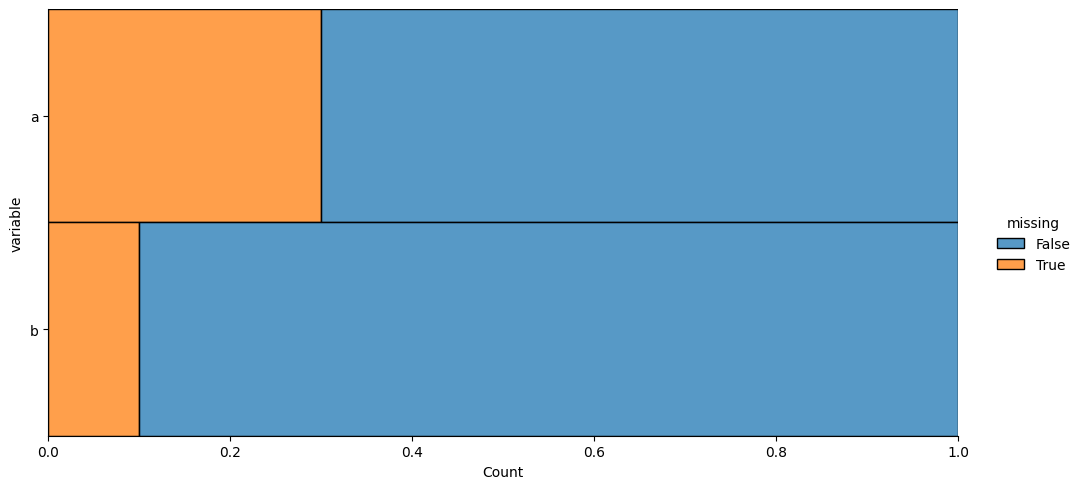

In [11]:
df.missing.missing_variable_plot()